In [1]:
import os
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append('..')
from src.models.auto_ets_adapter import create_autoets_adapter
from src.utils.metrics import nwrmsle

In [2]:
warnings.filterwarnings('ignore')

In [3]:
RAW_DATA_DIR = r"..\data\raw_data"
PREP_DATA_DIR = r"..\data\prepared_data"

In [4]:
train = pd.read_parquet(os.path.join(PREP_DATA_DIR, "train_filled_last3m.parquet"))
items = pd.read_csv(os.path.join(RAW_DATA_DIR, "items.csv"))
stores = pd.read_csv(os.path.join(RAW_DATA_DIR, "stores.csv"))

In [5]:
item_weights = items.set_index('item_nbr')['perishable'].to_dict()
item_weights = {k: 1.25 if v == 1 else 1.0 for k, v in item_weights.items()}

train_end_date = pd.Timestamp('2017-07-29')
val_end_date = pd.Timestamp('2017-08-14')

train_data = train[train['date'] <= train_end_date].copy()
val_data = train[(train['date'] > train_end_date) & (train['date'] <= val_end_date)].copy()
val_data['weight'] = val_data['item_nbr'].map(item_weights).fillna(1.0)

print(f"Train: {len(train_data)} записей")
print(f"Val: {len(val_data)} записей")
print(f"Уникальных пар в train: {train_data.groupby(['store_nbr', 'item_nbr']).ngroups}")

Train: 106124807 записей
Val: 2538176 записей
Уникальных пар в train: 174064


In [7]:
# Топ-50 пар для сравнения
pair_counts = train_data.groupby(['store_nbr', 'item_nbr']).size().sort_values(ascending=False)
sample_pairs = pair_counts.head(50).index.tolist()
print(f"Выбрано пар: {len(sample_pairs)}")

Выбрано пар: 50


In [8]:
ets_predictions = []

for idx, (store, item) in enumerate(sample_pairs):
    if idx % 10 == 0:
        print(f"Прогресс: {idx}/{len(sample_pairs)}")
    
    # Берем данные для этой пары
    pair_data = train_data[
        (train_data['store_nbr'] == store) & 
        (train_data['item_nbr'] == item)
    ].sort_values('date')
    
    if len(pair_data) < 30:
        continue
    
    # Обучающая выборка (все данные до валидации)
    train_series = pair_data['unit_sales'].iloc[:-16]
    
    # Обучаем AutoETS
    ets_model = create_autoets_adapter(forecast_horizon=16, season_length=7)
    ets_model.fit(train_series)
    
    # Прогнозируем
    forecast = ets_model.predict(pair_data['unit_sales'].iloc[-30:], horizon=16)
    
    # Сохраняем прогнозы
    last_date = pair_data['date'].max()
    for i, pred in enumerate(forecast):
        ets_predictions.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': last_date + pd.Timedelta(days=i+1),
            'predicted': max(0, pred)
        })

Прогресс: 0/50
Прогресс: 10/50
Прогресс: 20/50
Прогресс: 30/50
Прогресс: 40/50


In [9]:
# Собираем результаты
ets_pred_df = pd.DataFrame(ets_predictions)
print(f"Получено прогнозов: {len(ets_pred_df)}")

# Оцениваем на валидации
ets_val_with_pred = val_data.merge(
    ets_pred_df[['store_nbr', 'item_nbr', 'date', 'predicted']],
    on=['store_nbr', 'item_nbr', 'date'],
    how='inner'
)

Получено прогнозов: 800


In [10]:
if len(ets_val_with_pred) > 0:
    ets_score = nwrmsle(
        ets_val_with_pred['unit_sales'].values,
        ets_val_with_pred['predicted'].values,
        ets_val_with_pred['weight'].values
    )
    print(f"AutoETS Direct NWRMSLE: {ets_score:.6f}")

AutoETS Direct NWRMSLE: 0.542941


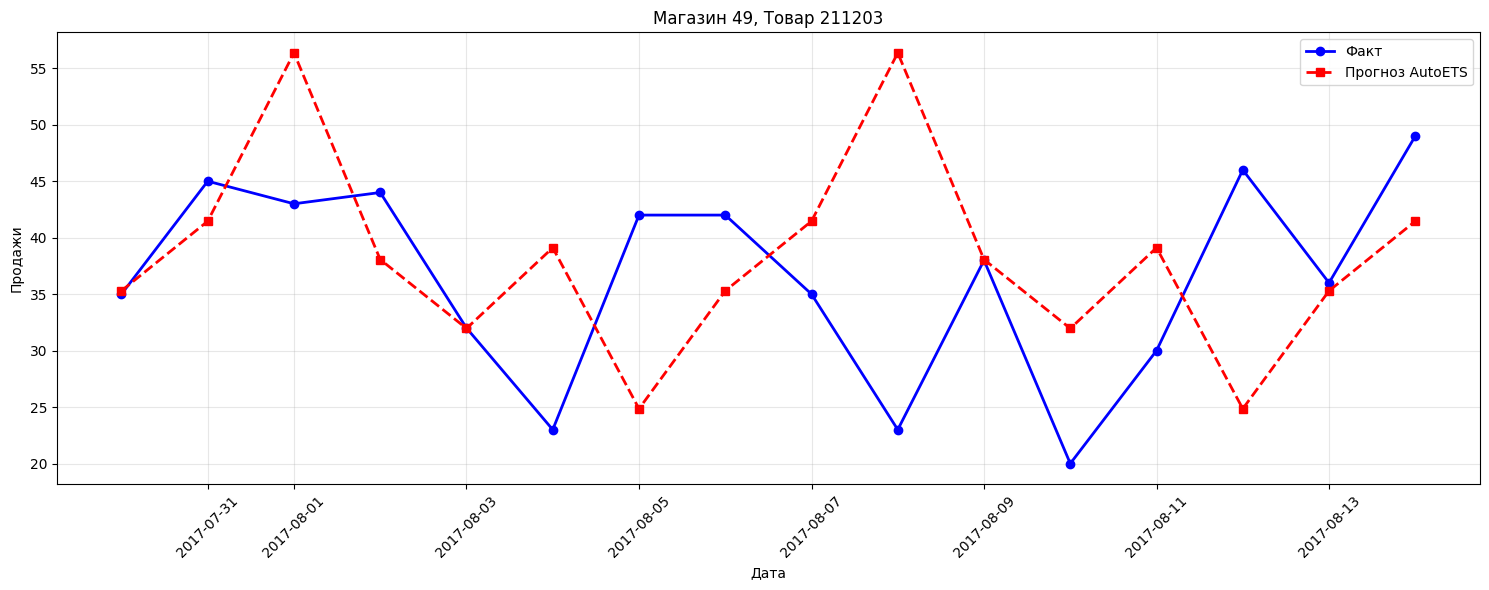

In [11]:
example_store, example_item = sample_pairs[10]
example_data = ets_val_with_pred[
    (ets_val_with_pred['store_nbr'] == example_store) & 
    (ets_val_with_pred['item_nbr'] == example_item)
].sort_values('date')

if len(example_data) > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(example_data['date'], example_data['unit_sales'], 'b-', label='Факт', linewidth=2, marker='o')
    plt.plot(example_data['date'], example_data['predicted'], 'r--', label='Прогноз AutoETS', linewidth=2, marker='s')
    plt.title(f'Магазин {example_store}, Товар {example_item}')
    plt.xlabel('Дата')
    plt.ylabel('Продажи')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()